# 📉 Optimización con LASSO (Least Absolute Shrinkage and Selection Operator)
## Implementación From Scratch y Validación

Este notebook documenta la implementación manual del algoritmo de Descenso por Coordenadas para la regresión regularizada con penalización $L_1$ (LASSO), utilizando el dataset de precios de viviendas en Lima.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold
import warnings
warnings.filterwarnings('ignore')

# Importamos la función compartida de preprocesamiento
import sys
sys.path.append('../src')
from preprocessing import get_housing_data

# IMPORT CORREGIDO: Importamos la clase exacta de Pedro
from lasso_manual import LassoManual

### 1. Carga y Preprocesamiento de Datos
Utilizamos el pipeline centralizado para garantizar que ambos equipos (LASSO y Elastic Net) evalúen sus modelos bajo las mismas condiciones exactas, evitando fuga de datos (*data leakage*).

In [4]:
ruta_datos = '../data/housing_lima_final.xlsx'

# Extraemos las matrices listas para la matemática

X_train, X_test, y_train, y_test, feature_cols, scaler = get_housing_data(ruta_datos)

print("=" * 50)
print(" 🏠 DATASET: Housing Prices Lima (LASSO)")
print("=" * 50)
print(f"Train:  {X_train.shape[0]} observaciones")
print(f"Test:   {X_test.shape[0]} observaciones")
print(f"Predictores: {len(feature_cols)} variables estandarizadas")

 🏠 DATASET: Housing Prices Lima (LASSO)
Train:  5675 observaciones
Test:   1419 observaciones
Predictores: 70 variables estandarizadas


### 2. Búsqueda del Hiperparámetro Óptimo ($\lambda$)
A diferencia de Elastic Net, LASSO solo requiere calibrar el parámetro de penalización $\lambda$. Utilizaremos validación cruzada de 5 pliegues (5-Fold CV).

In [5]:
print("\n" + "─" * 50)
print(" 🔍 BÚSQUEDA DE HIPERPARÁMETRO (5-Fold CV)")
print("─" * 50)

# Scikit-learn y Pedro usan 'alpha', así que lo llamaremos alpha en el código
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
best_mse = np.inf
best_alpha = None
cv_results = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for a in alphas:
    fold_mses = []
    for train_idx, val_idx in kf.split(X_train):
        Xtr, Xval = X_train[train_idx], X_train[val_idx]
        ytr, yval = y_train[train_idx], y_train[val_idx]

        # CORREGIDO: Usamos LassoManual y el parámetro alpha
        model = LassoManual(alpha=a, max_iter=500, tol=1e-5)
        model.fit(Xtr, ytr)
        y_pred_val = model.predict(Xval)
        fold_mses.append(mean_squared_error(yval, y_pred_val))

    mean_mse = np.mean(fold_mses)
    cv_results.append({'alpha': a, 'cv_mse': mean_mse})

    if mean_mse < best_mse:
        best_mse = mean_mse
        best_alpha = a

print(f"Mejor alpha (λ en teoría): {best_alpha}")
print(f"Mejor CV-MSE:             {best_mse:.6f}")


──────────────────────────────────────────────────
 🔍 BÚSQUEDA DE HIPERPARÁMETRO (5-Fold CV)
──────────────────────────────────────────────────
Mejor alpha (λ en teoría): 0.001
Mejor CV-MSE:             0.134687


### 3. Entrenamiento Final y Evaluación
Entrenamos el modelo definitivo con el mejor $\lambda$ encontrado.

In [6]:
# CORREGIDO: Usamos LassoManual y best_alpha
model_scratch = LassoManual(alpha=best_alpha, max_iter=2000, tol=1e-7)
model_scratch.fit(X_train, y_train)

y_pred_train = model_scratch.predict(X_train)
y_pred_test  = model_scratch.predict(X_test)

mse_test  = mean_squared_error(y_test, y_pred_test)
r2_test   = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)

n_zeros   = np.sum(model_scratch.coef_ == 0)
n_nonzero = np.sum(model_scratch.coef_ != 0)

print(f"Métricas en Test -> R²: {r2_test:.4f} | RMSE: {rmse_test:.4f}")
print(f"Selección LASSO  -> Activas: {n_nonzero} | Anuladas (Cero exacto): {n_zeros}")

Métricas en Test -> R²: 0.7713 | RMSE: 0.4009
Selección LASSO  -> Activas: 61 | Anuladas (Cero exacto): 9


### 4. Validación contra Scikit-Learn
Comparamos nuestra implementación manual contra la librería optimizada de la industria. *Nota: Scikit-learn llama `alpha` a nuestro parámetro `lambda`.*

In [7]:
model_sklearn = Lasso(alpha=best_alpha, max_iter=10000, tol=1e-8)
model_sklearn.fit(X_train, y_train)

y_pred_sk = model_sklearn.predict(X_test)
r2_sk     = r2_score(y_test, y_pred_sk)
mse_sk    = mean_squared_error(y_test, y_pred_sk)

max_coef_diff = np.max(np.abs(model_scratch.coef_ - model_sklearn.coef_))

print(f"{'Métrica':<20} {'Scratch':>12} {'Sklearn':>12} {'Diferencia':>12}")
print("-" * 58)
print(f"{'R² Test':<20} {r2_test:>12.6f} {r2_sk:>12.6f} {abs(r2_test-r2_sk):>12.2e}")
print(f"{'MSE Test':<20} {mse_test:>12.6f} {mse_sk:>12.6f} {abs(mse_test-mse_sk):>12.2e}")
print(f"{'Max Diff Coef':<20} {'-':>12} {'-':>12} {max_coef_diff:>12.2e}")

Métrica                   Scratch      Sklearn   Diferencia
----------------------------------------------------------
R² Test                  0.771330     0.771330     5.94e-08
MSE Test                 0.160685     0.160685     4.17e-08
Max Diff Coef                   -            -     5.50e-07


### 5. Regularization Path y Gráficas
Visualizamos geométricamente cómo la penalización $L_1$ fuerza a los coeficientes a colapsar exactamente a cero.

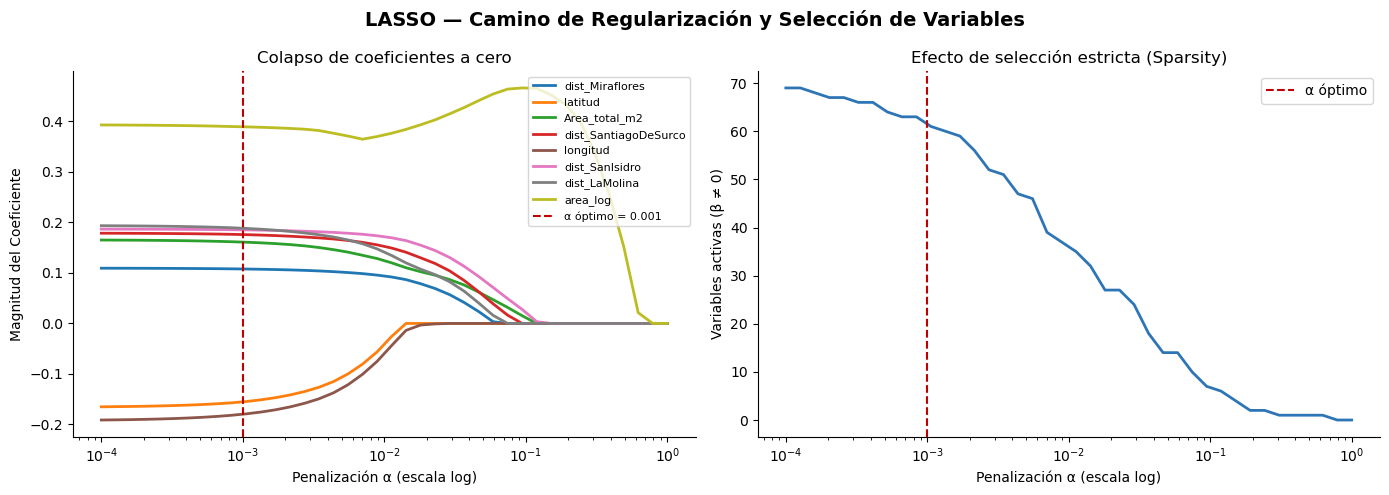

In [8]:
# 1. Calcular el camino de regularización manualmente
alphas_path = np.logspace(-4, 0, 40)
coef_path = []

for a in alphas_path:
    # CORREGIDO: LassoManual y alpha=a
    m = LassoManual(alpha=a, max_iter=500, tol=1e-5)
    m.fit(X_train, y_train)
    coef_path.append(m.coef_.copy())

coef_path = np.array(coef_path)

# Identificar las variables más fuertes
opt_idx = np.argmin(np.abs(alphas_path - best_alpha))
top_idx = np.argsort(np.abs(coef_path[opt_idx]))[-8:]
top_names = [feature_cols[i] for i in top_idx]

# 2. Configurar estilo visual simétrico al otro equipo
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREEN, GRAY = '#2E75B6', '#C00000', '#70AD47', '#595959'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LASSO — Camino de Regularización y Selección de Variables', fontsize=14, fontweight='bold')

# Gráfico A: Camino de Regularización
ax = axes[0]
cmap = plt.cm.tab10
for i, (idx, name) in enumerate(zip(top_idx, top_names)):
    ax.plot(alphas_path, coef_path[:, idx], label=name, color=cmap(i/8), linewidth=2)
ax.axvline(best_alpha, color=RED, linestyle='--', label=f'α óptimo = {best_alpha}')
ax.set_xscale('log')
ax.set_xlabel('Penalización α (escala log)')
ax.set_ylabel('Magnitud del Coeficiente')
ax.set_title('Colapso de coeficientes a cero')
ax.legend(fontsize=8)

# Gráfico B: Conteo de variables activas
ax = axes[1]
n_active = [np.sum(coef_path[i] != 0) for i in range(len(alphas_path))]
ax.plot(alphas_path, n_active, color=BLUE, linewidth=2)
ax.axvline(best_alpha, color=RED, linestyle='--', label=f'α óptimo')
ax.set_xscale('log')
ax.set_xlabel('Penalización α (escala log)')
ax.set_ylabel('Variables activas (β ≠ 0)')
ax.set_title('Efecto de selección estricta (Sparsity)')
ax.legend()

plt.tight_layout()
plt.show()